In [2]:
from typing import Callable
import numpy as np
import matplotlib.pyplot as plt
EPSILON = np.finfo(float).eps

In [3]:
tab = [3,4]
i = tab.index(min(tab))

In [4]:
x = 1.0
fun = np.tan
h_array = 10.0 ** -np.arange(0, 17)

In [5]:
exact_d1 = 1.0 + np.tan(x) ** 2
exact_d2 = 2.0 * np.tan(x) * (1.0 + np.tan(x) ** 2)
exact_d3 = (2.0 + 6.0 * np.tan(x) ** 2) * (1.0 + np.tan(x) ** 2)

In [6]:
def deriv_forward(x: float, h: float, func: Callable):
    return (func(x + h) - func(x)) / h

def deriv_central(x: float, h: float, func: Callable):
    return (func(x + h) - func(x - h)) / (2.0 * h)

In [7]:
res_deriv_forward = np.array([deriv_forward(x, h, fun) for h in h_array])

#relative_error_forward = np.array([abs(res - exact_d1) for res in res_deriv_forward])
#non_relative_error_forward = np.array([abs(res - exact_d1) / abs(exact_d1) for res in res_deriv_forward])

M2_forward = abs(exact_d2)
h_min_forward = 2.0 * np.sqrt(EPSILON / M2_forward)

numerical_error_forward = 2.0 * EPSILON / h_array
truncation_error_forward = M2_forward * h_array / 2.0
computational_error_forward = truncation_error_forward + numerical_error_forward

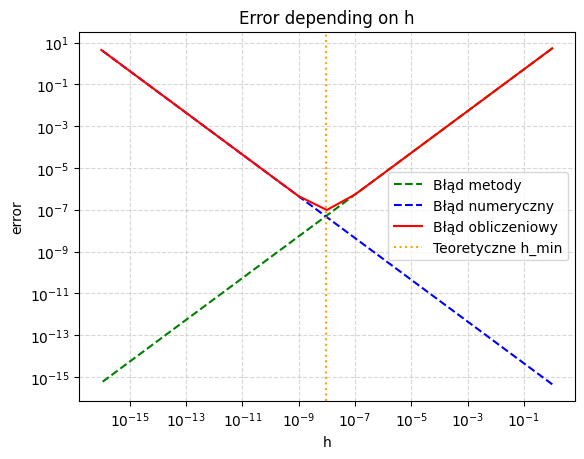

In [8]:
plt.loglog(h_array, truncation_error_forward, 'g--', label='Błąd metody')
plt.loglog(h_array, numerical_error_forward, 'b--', label='Błąd numeryczny')
plt.loglog(h_array, computational_error_forward, 'r-', label='Błąd obliczeniowy')
plt.axvline(h_min_forward, color='orange', linestyle=':', label='Teoretyczne h_min')
plt.title("Error depending on h")
plt.xlabel("h")
plt.ylabel("error")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

In [9]:
print(f"forward theoretical h min: {h_min_forward}")
print(f"forward theoretical error value: {2.0*EPSILON/h_min_forward + M2_forward*h_min_forward/2.0}\n")
print(f"forward calculated h min: {h_array[np.where(computational_error_forward == min(computational_error_forward))][0]}",)
print(f"forward calculated error value: {min(computational_error_forward)}")

forward theoretical h min: 9.123695225180451e-09
forward theoretical error value: 9.734854110962026e-08

forward calculated h min: 1e-08
forward calculated error value: 9.775821570988286e-08


In [10]:
res_deriv_central = np.array([deriv_central(x, h, fun) for h in h_array])

M3_central = exact_d3
h_min_central = (3.0*EPSILON / M3_central)**(1/3)

numerical_error_central = EPSILON / h_array
truncation_error_central = M3_central * h_array**2 / 6.0
computational_error_central = truncation_error_central + numerical_error_central

#relative_error_central = np.array([abs(res - exact_d1) for res in res_deriv_central])
#non_relative_error_central = np.array([abs(res - exact_d1) / abs(exact_d1) for res in res_deriv_central])

In [11]:
print(f"central theoretical h min: {h_min_central}")
print(f"central theoretical error value: {EPSILON/h_min_forward + M3_central*h_min_forward**2/6.0}\n")
print(f"central calculated h min: {h_array[np.where(computational_error_central == min(computational_error_central))][0]}",)
print(f"central calculated error value: {min(computational_error_central)}")

central theoretical h min: 2.2732741568390634e-06
central theoretical error value: 2.4337136064081833e-08

central calculated h min: 1e-06
central calculated error value: 2.3149510490291096e-10


In [12]:
#print(f'{ res_deriv_forward = }')
#print(f'{ relative_error_forward = }')
#print(f'{ non_relative_error_forward = }')

#print(f'{ res_deriv_central = }')
#print(f'{ relative_error_central = }')
#print(f'{ non_relative_error_central = }')